In [1]:
#hw3_rev2

import pandas as pd
import numpy as np
import cv2
import os
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, Lambda
from tensorflow.keras.layers import Dropout
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# --- Config ---
IMAGE_HEIGHT, IMAGE_WIDTH = 66, 200
BATCH_SIZE = 32
EPOCHS = 30

image_folder = r"C:\Users\markg\Downloads\ZigZag_Driving\ZigZag_Driving\3"

# Load their CSV
df = pd.read_csv(r"C:\Users\markg\Downloads\ZigZag_Driving\robot_log.csv", delimiter=';')

# Drop rows where necessary columns are missing
df = df.dropna(subset=['Path', 'SteerAngle', 'Throttle'])

# Extract just the filename from the 'Path' column (in case it's a full path)
df['ImageFile'] = df['Path'].apply(lambda p: os.path.basename(p))

# New function to load images from the image folder using filename
def load_image(filename):
    full_path = os.path.join(image_folder, filename)
    image = cv2.imread(full_path)
    if image is None:
        raise FileNotFoundError(f"Image not found: {full_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMAGE_WIDTH, IMAGE_HEIGHT))
    return image / 255.0

# Load all images
print("Loading new dataset images...")
images = np.array([load_image(fname) for fname in df['ImageFile']])

# Extract labels
steering = df['SteerAngle'].astype(np.float32).values
throttle = df['Throttle'].astype(np.float32).values

Loading new dataset images...



Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 71.1038 - steering_output_loss: 70.5935 - steering_output_mae: 6.4530 - throttle_output_loss: 0.5101 - throttle_output_mae: 0.5557 - val_loss: 65.2932 - val_steering_output_loss: 65.3517 - val_steering_output_mae: 6.1785 - val_throttle_output_loss: 0.1725 - val_throttle_output_mae: 0.3526
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 57.1569 - steering_output_loss: 56.8727 - steering_output_mae: 5.9068 - throttle_output_loss: 0.2841 - throttle_output_mae: 0.4147 - val_loss: 51.0781 - val_steering_output_loss: 51.1218 - val_steering_output_mae: 5.4253 - val_throttle_output_loss: 0.1848 - val_throttle_output_mae: 0.3469
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 46.2238 - steering_output_loss: 45.9463 - steering_output_mae: 5.1767 - throttle_output_loss: 0.2780 - throttle_output_mae: 0.4152 - val_loss: 50.2470 - val_steering_output_loss: 50.0404 - val_steering_output_mae: 5.3967 - val_throttle_output

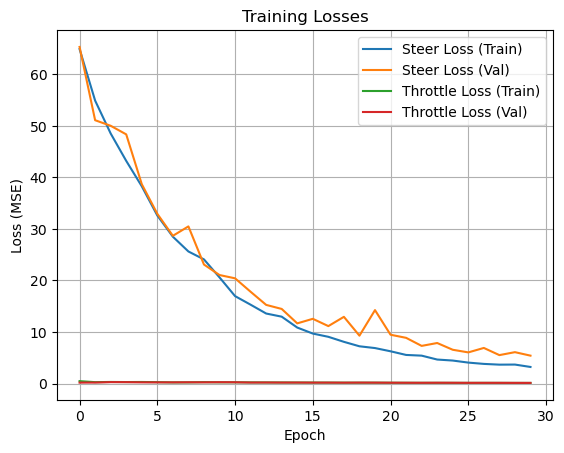

In [2]:
# --- Train/test split ---
X_train, X_test, y_steer_train, y_steer_test, y_throttle_train, y_throttle_test = train_test_split(
    images, steering, throttle, test_size=0.2, random_state=42
)

# --- Build the dual-output CNN ---
inputs = Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))

x = Lambda(lambda x: x)(inputs)
x = Conv2D(24, (5, 5), strides=(2, 2), activation='relu')(x)
x = Conv2D(36, (5, 5), strides=(2, 2), activation='relu')(x)
x = Conv2D(48, (5, 5), strides=(2, 2), activation='relu')(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = Flatten()(x)
x = Dense(100, activation='relu')(x)
x = Dense(50, activation='relu')(x)
x = Dense(10, activation='relu')(x)

steer_output = Dense(1, name='steering_output')(x)
throttle_output = Dense(1, name='throttle_output')(x)

model = Model(inputs=inputs, outputs=[steer_output, throttle_output])

model.compile(optimizer='adam',
              loss={'steering_output': 'mse', 'throttle_output': 'mse'}, 
              metrics={'steering_output': 'mae', 'throttle_output': 'mae'})

# --- Train the model ---
history = model.fit(
    X_train,
    {'steering_output': y_steer_train, 'throttle_output': y_throttle_train},
    validation_data=(X_test, {'steering_output': y_steer_test, 'throttle_output': y_throttle_test}),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# --- Plot loss curves ---
plt.plot(history.history['steering_output_loss'], label='Steer Loss (Train)')
plt.plot(history.history['val_steering_output_loss'], label='Steer Loss (Val)')
plt.plot(history.history['throttle_output_loss'], label='Throttle Loss (Train)')
plt.plot(history.history['val_throttle_output_loss'], label='Throttle Loss (Val)')
plt.title('Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid()
plt.show()

# --- Save the model ---
model.save("mars_rover_dual_output_cnn.keras")

In [3]:
# Predict on test images
pred_steer, pred_throttle = model.predict(X_test)

# Flatten outputs for comparison
pred_steer = pred_steer.flatten()
pred_throttle = pred_throttle.flatten()

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


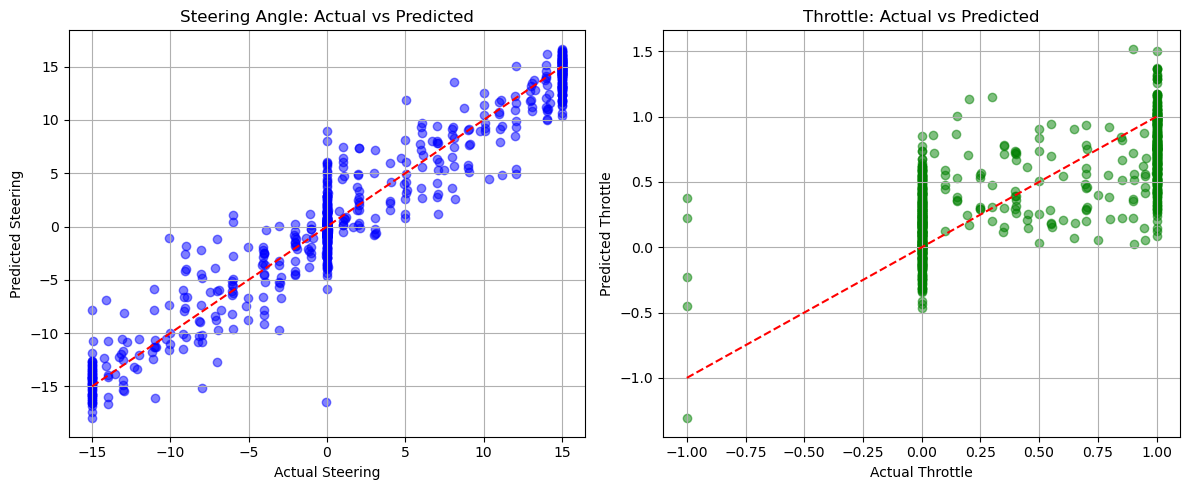

In [4]:
#Plot predicted vs. actual values to test model fit
import matplotlib.pyplot as plt

# Steering Angle
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_steer_test, pred_steer, alpha=0.5, color='blue')
plt.plot([min(y_steer_test), max(y_steer_test)],
         [min(y_steer_test), max(y_steer_test)],
         color='red', linestyle='--')  # perfect prediction line
plt.title('Steering Angle: Actual vs Predicted')
plt.xlabel('Actual Steering')
plt.ylabel('Predicted Steering')
plt.grid(True)

# Throttle
plt.subplot(1, 2, 2)
plt.scatter(y_throttle_test, pred_throttle, alpha=0.5, color='green')
plt.plot([min(y_throttle_test), max(y_throttle_test)],
         [min(y_throttle_test), max(y_throttle_test)],
         color='red', linestyle='--')  # perfect prediction line
plt.title('Throttle: Actual vs Predicted')
plt.xlabel('Actual Throttle')
plt.ylabel('Predicted Throttle')
plt.grid(True)

plt.tight_layout()
plt.show()

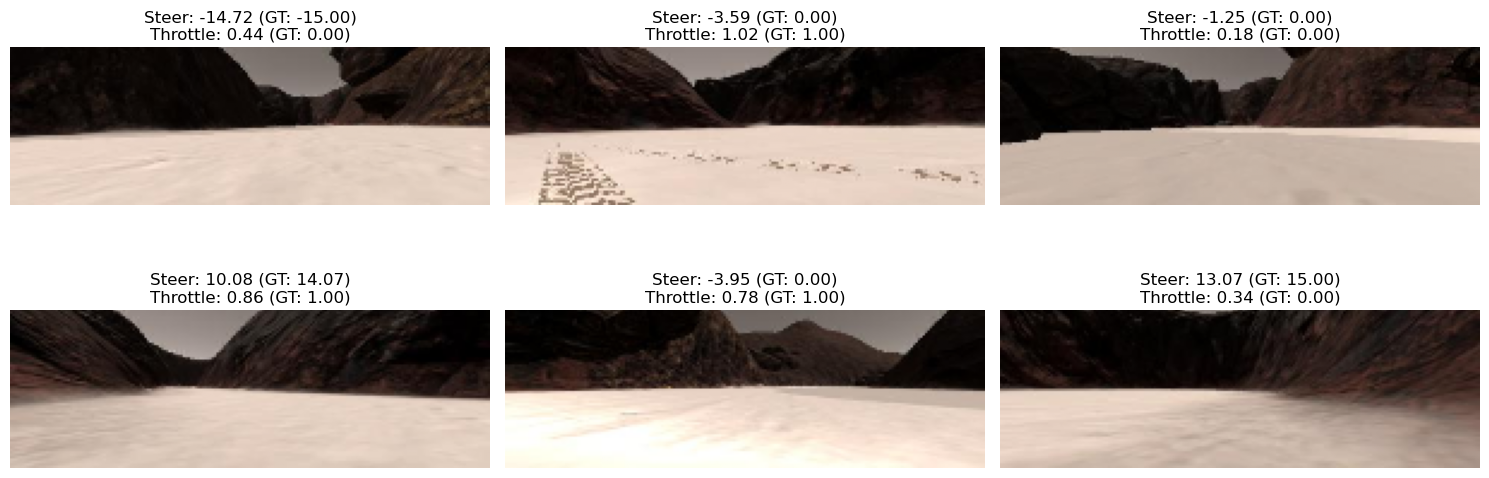

In [5]:
#plot random sample images with predicted outputs based on model
import random

# Show a few samples with image + predicted vs actual
num_samples = 6
indices = random.sample(range(len(X_test)), num_samples)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(indices):
    img = X_test[idx]
    true_s = y_steer_test[idx]
    true_t = y_throttle_test[idx]
    pred_s = pred_steer[idx]
    pred_t = pred_throttle[idx]
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Steer: {pred_s:.2f} (GT: {true_s:.2f})\nThrottle: {pred_t:.2f} (GT: {true_t:.2f})")
    plt.axis('off')

plt.tight_layout()
plt.show()